In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Libraries

In [46]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from collections import Counter
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score


# Load Dataset

In [4]:
# Point to the root directory containing dataset
data_path = '/content/drive/MyDrive/AI_&_ML/CNN/Datasets/Bharatanatyam_Mudras'

class_names = os.listdir(data_path)
print('Class names\n', class_names)

Class names
 ['Trisula', 'Musti', 'Sikhara', 'Simhamukha', 'Pataka']


In [6]:
class_distribution = {}
image_size = []
corrupted_images = []

for mudra in class_names:
    class_path = os.path.join(data_path, mudra)
    images = os.listdir(class_path)
    class_distribution[mudra] = len(images)

    for img_name in images:
        img_path = os.path.join(class_path, img_name)
        try:
            img = cv2.imread(img_path)
            if img is None:
                corrupted_images.append(img_path)
            else:
                image_size.append(img.shape)
        except:
            corrupted_images.append(img_path)

print("Class Distribution:")
for mudra, count in class_distribution.items():
    print(f"{mudra}: {count} images")

print("\nTotal images:", sum(class_distribution.values()))
print("Corrupted images:", len(corrupted_images))

Class Distribution:
Trisula: 400 images
Musti: 400 images
Sikhara: 400 images
Simhamukha: 400 images
Pataka: 400 images

Total images: 2000
Corrupted images: 0


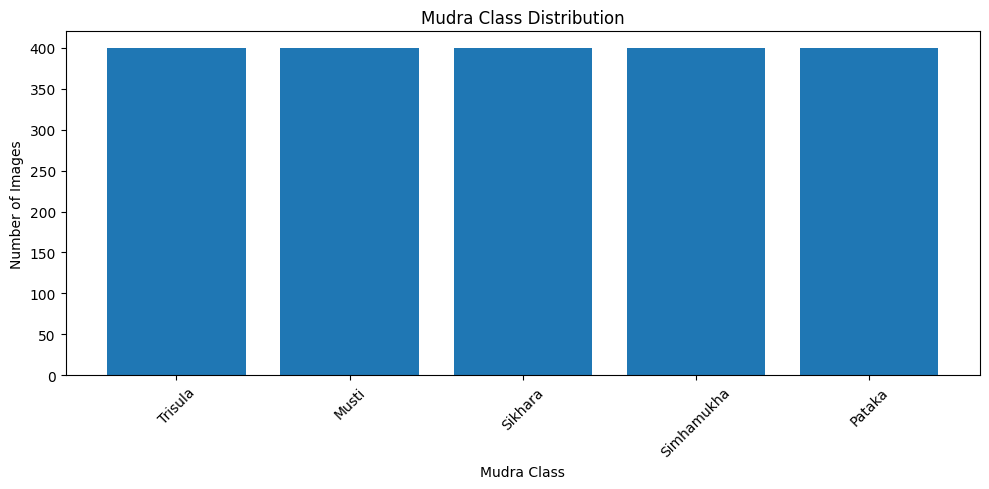

In [9]:
# Visualization
plt.figure(figsize=(10, 5))
plt.bar(class_distribution.keys(), class_distribution.values())
plt.title("Mudra Class Distribution")
plt.xlabel("Mudra Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("class_distribution.png")
plt.show()

In [8]:
# Image size analysis
df_size = pd.DataFrame(image_size, columns=['Height', 'Width', 'Channels'])
print(df_size.describe())

       Height   Width  Channels
count  2000.0  2000.0    2000.0
mean    300.0   300.0       3.0
std       0.0     0.0       0.0
min     300.0   300.0       3.0
25%     300.0   300.0       3.0
50%     300.0   300.0       3.0
75%     300.0   300.0       3.0
max     300.0   300.0       3.0


### Analytical questions
1. Data is balanced. If data is imbalanced model learns to predict majority class more often
2. Low contrast, motion blur, poor lighting, background clutter, extreme brightness/darkness, unusual rotation angles, scale variation
3. No, because higher resolution shows diminishing accuracy.

# Preprocessing

In [18]:
# Load and preprocess images
img_size = 128
btch_size = 32

# Create empty lists to store images and labels
images = []
labels = []

# Loop through each mudra class
for idx, mudra in enumerate(class_names):
    class_path = os.path.join(data_path, mudra)
    # Loop through each image in the current mudra class directory
    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Convert BGR to RGB
            img = cv2.resize(img, (img_size, img_size)) # Resize to img_size
            images.append(img)
            labels.append(idx)

# Convert lists to numpy arrays
images = np.array(images)
labels = np.array(labels)

# Normalize images
images = images.astype('float32') / 255.0

print(f"Total images loaded: {len(images)}")
print(f"Shape of images array: {images.shape}")
print(f"Shape of labels array: {labels.shape}")

# Split dataset into 70% train, 15% validation and 15% test
X_train, X_temp, y_train, y_temp = train_test_split(images, labels, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print("Training set:", len(X_train))
print("Validation set:", len(X_val))
print("Test set:", len(X_test))

Training set: 1400
Validation set: 300
Test set: 300


In [30]:
# Data augmentation for training
train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)
# No augmentation for validation and test
val_test_datagen = ImageDataGenerator()

# Apply augmentation
train_generator = train_datagen.flow(X_train, y_train, batch_size=btch_size)
val_generator = val_test_datagen.flow(X_val, y_val, batch_size=btch_size)
test_generator = val_test_datagen.flow(X_test, y_test, batch_size=btch_size, shuffle=False)

print("Data augmentation applied successfully!")

Data augmentation applied successfully!


### Analytical questions
1. Rotation , zoom,brightness changes and position shifts
2. Horizontal flip, vertical flip, extreme rotation

# Model Building

In [31]:
# CNN
custom_model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(img_size, img_size, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(256, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(5, activation='softmax')  # 5 mudra classes
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [32]:
# Compile model
model = custom_model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print(model.summary())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │     4,719,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,242,053 (20.00 MB)

 Trainable params: 5,241,093 (19.99 MB)

 Non-trainable params: 960 (3.75 KB)

None


In [33]:
# Training
print('\n Training started.....')


history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20
)



 Training started.....
Epoch 1/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 84s 2s/step - accuracy: 0.4714 - loss: 2.8275 - val_accuracy: 0.2733 - val_loss: 2.7438
Epoch 2/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.6993 - loss: 1.1482 - val_accuracy: 0.2233 - val_loss: 11.6880
Epoch 3/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 78s 2s/step - accuracy: 0.7779 - loss: 0.7982 - val_accuracy: 0.2233 - val_loss: 24.1328
Epoch 4/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 107s 2s/step - accuracy: 0.8379 - loss: 0.5775 - val_accuracy: 0.2233 - val_loss: 40.4072
Epoch 5/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 94s 2s/step - accuracy: 0.8621 - loss: 0.5136 - val_accuracy: 0.2233 - val_loss: 35.0442
Epoch 6/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 112s 3s/step - accuracy: 0.8929 - loss: 0.3971 - val_accuracy: 0.2233 - val_loss: 30.4642
Epoch 7/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - accuracy: 0.9029 - loss: 0.3567 - val_accuracy: 0.2233 - val_loss: 38.5833
Epoch 8/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 102s 2s/step - accuracy: 0.9171 - loss: 0.3047 -

In [34]:
# Save model
model.save('mudra_classifier_model.h5')
print("Model saved!")

Model saved!


## Hyperparameter

In [50]:
# Grid Search

learning_rates = [0.0001, 0.0005, 0.001, 0.005]
batch_sizes = [16, 32, 64]
dropout_rates = [0.2, 0.3, 0.5]
l2_regularizers = [0.0001, 0.001, 0.01]

results = []

for lr in learning_rates:
    for batch_size in batch_sizes:
        for dropout in dropout_rates:
            for l2 in l2_regularizers:
                print(f"\nTesting: LR={lr}, Batch={batch_size}, Dropout={dropout}, L2={l2}")

                model = models.Sequential([
                    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(img_size, img_size, 3), kernel_regularizer=tf.keras.regularizers.l2(l2)),
                    layers.BatchNormalization(),
                    layers.MaxPooling2D((2, 2)),

                    layers.Conv2D(64, (3, 3), activation='relu', kernel_regularizer=tf.keras.regularizers.l2(l2)),
                    layers.BatchNormalization(),
                    layers.MaxPooling2D((2, 2)),

                    layers.Conv2D(128, (3, 3), activation='relu', kernel_regularizer=tf.keras.regularizers.l2(l2)),
                    layers.BatchNormalization(),
                    layers.MaxPooling2D((2, 2)),

                    layers.Flatten(),
                    layers.Dense(512, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(l2)),
                    layers.Dropout(dropout),
                    layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(l2)),
                    layers.Dropout(dropout),
                    layers.Dense(5, activation='softmax')
                ])

                model.compile(
                    optimizer=Adam(learning_rate=lr),
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy']
                )

                history = model.fit(
                    train_generator,
                    validation_data=val_generator,
                    epochs=5
                )

                val_accuracy = history.history['val_accuracy'][-1]
                results.append({
                    'learning_rate': lr,
                    'batch_size': batch_size,
                    'dropout': dropout,
                    'l2_reg': l2,
                    'val_accuracy': val_accuracy
                })

                print(f"Validation Accuracy: {val_accuracy:.4f}")

# Find best hyperparameters
best_result = max(results, key=lambda x: x['val_accuracy'])
print("\n" + "="*60)
print("BEST HYPERPARAMETERS:")
print("="*60)
print(f"Learning Rate: {best_result['learning_rate']}")
print(f"Batch Size: {best_result['batch_size']}")
print(f"Dropout: {best_result['dropout']}")
print(f"L2 Regularization: {best_result['l2_reg']}")
print(f"Validation Accuracy: {best_result['val_accuracy']:.4f}")


Testing: LR=0.0001, Batch=16, Dropout=0.2, L2=0.0001


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step - accuracy: 0.5757 - loss: 1.4388 - val_accuracy: 0.3967 - val_loss: 2.0584
Epoch 2/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 94s 2s/step - accuracy: 0.7879 - loss: 0.7087 - val_accuracy: 0.2233 - val_loss: 3.0515
Epoch 3/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step - accuracy: 0.8571 - loss: 0.5269 - val_accuracy: 0.2233 - val_loss: 4.1184
Epoch 4/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.9086 - loss: 0.3901 - val_accuracy: 0.2967 - val_loss: 4.3018
Epoch 5/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 84s 2s/step - accuracy: 0.9179 - loss: 0.3788 - val_accuracy: 0.3733 - val_loss: 4.6314
Validation Accuracy: 0.3733

Testing: LR=0.0001, Batch=16, Dropout=0.2, L2=0.001
Epoch 1/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 86s 2s/step - accuracy: 0.5621 - loss: 2.7830 - val_accuracy: 0.3500 - val_loss: 3.2452
Epoch 2/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.7886 - loss: 2.0243 - val_accuracy: 0.3500 - val_loss: 3.9454
Epoch 3/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/

KeyboardInterrupt: 

In [51]:
# Visualize results
results_df = pd.DataFrame(results)
print("\nTop 10 Configurations:")
print(results_df.nlargest(10, 'val_accuracy'))


Top 10 Configurations:
   learning_rate  batch_size  dropout  l2_reg  val_accuracy
3         0.0001          16      0.3  0.0001      0.396667
4         0.0001          16      0.3  0.0010      0.376667
0         0.0001          16      0.2  0.0001      0.373333
1         0.0001          16      0.2  0.0010      0.363333
2         0.0001          16      0.2  0.0100      0.276667


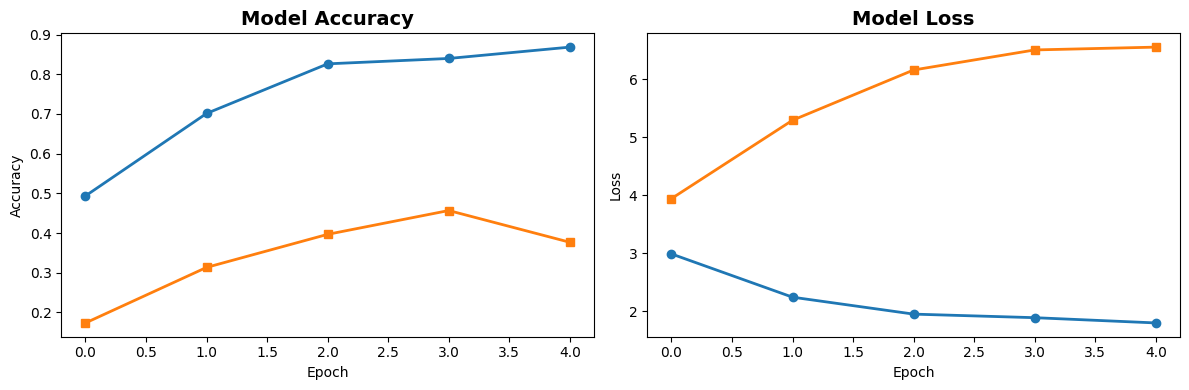

Training/Validation curves saved!


In [52]:
# Simple Training vs Validation Accuracy
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', linewidth=2, marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2, marker='s')
plt.title('Model Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', linewidth=2, marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2, marker='s')
plt.title('Model Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.tight_layout()
plt.savefig('training_validation_curves.png', dpi=300)
plt.show()

print("Training/Validation curves saved!")

# Model Evaluation and Failure Analysis

## Evaluate

In [35]:
# Evaluate on test set
y_prediction = model.predict(X_test)
y_pred = np.argmax(y_prediction, axis=1)

10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 348ms/step


In [38]:
# Evaluate the model:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Accuracy: 0.6566666666666666
Precision: 0.8155387205387206
Recall: 0.6566666666666666
F1-score: 0.5655446349781273


In [39]:
# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))


Classification Report:
              precision    recall  f1-score   support

     Trisula       0.50      1.00      0.67        63
       Musti       0.60      1.00      0.75        59
     Sikhara       1.00      0.20      0.33        51
  Simhamukha       1.00      0.03      0.06        64
      Pataka       1.00      1.00      1.00        63

    accuracy                           0.66       300
   macro avg       0.82      0.65      0.56       300
weighted avg       0.82      0.66      0.57       300



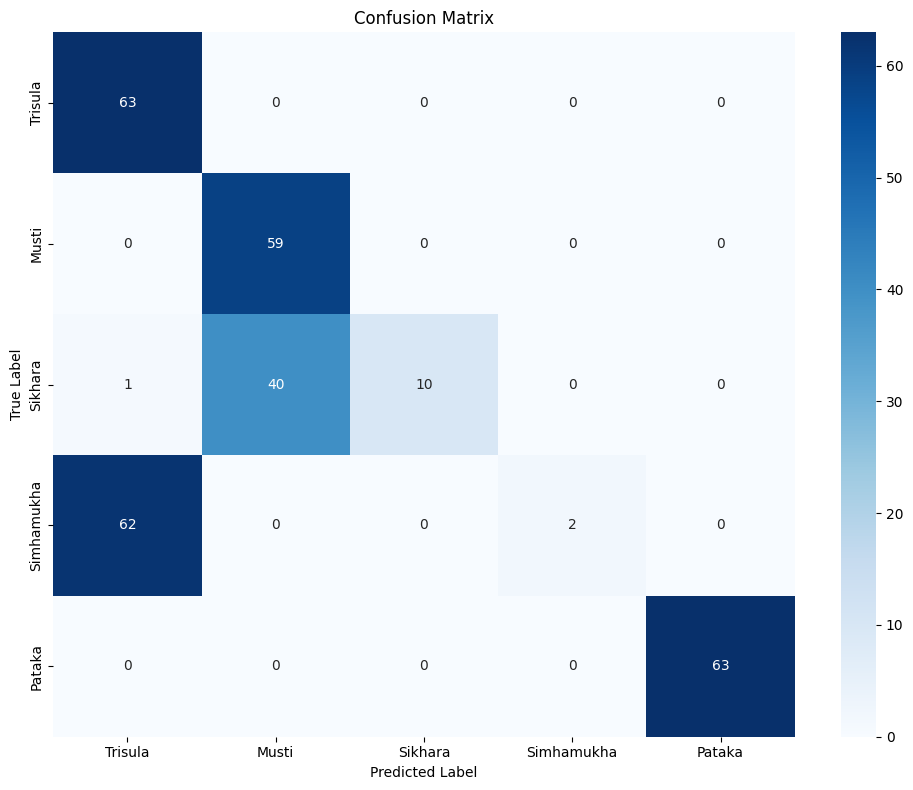

In [40]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()

## Plot training history

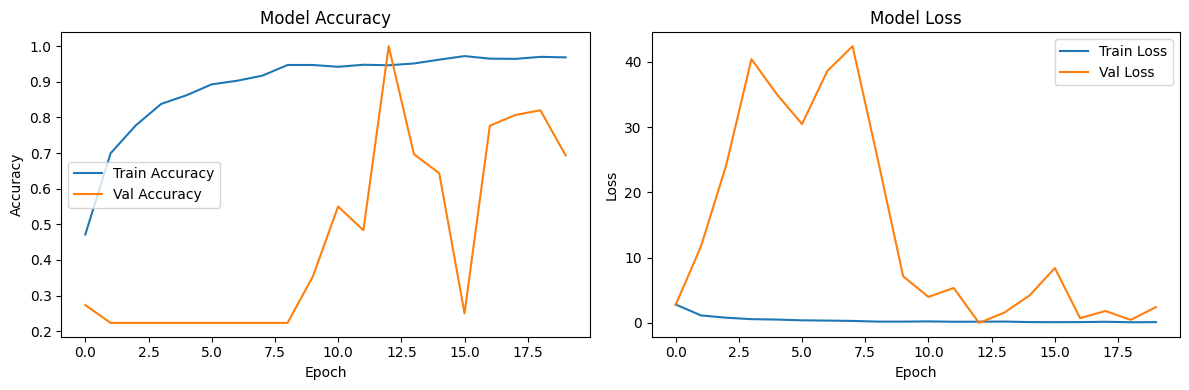

In [41]:

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.savefig("training_history.png")
plt.show()

## Failure Analysis

In [42]:
misclassified = np.where(y_pred != y_test)[0]
print(f"\nMisclassified images: {len(misclassified)} out of {len(y_test)}")


Misclassified images: 103 out of 300


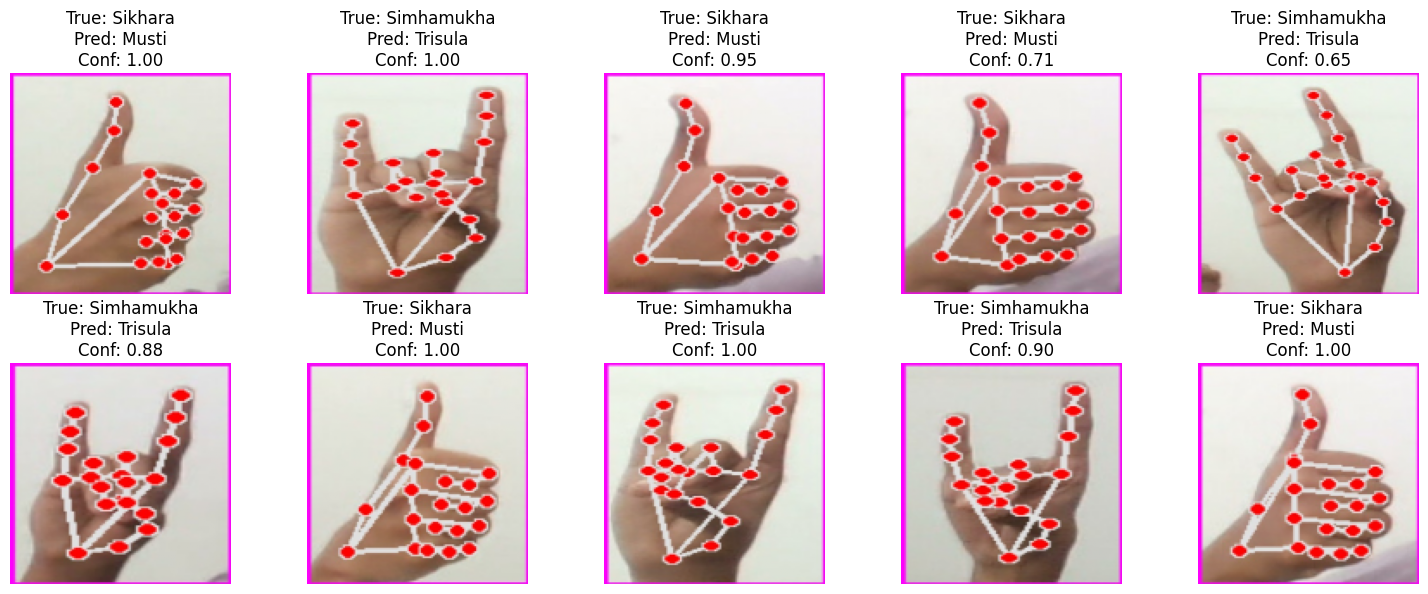

In [44]:
# Visualize top misclassifications
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i, idx in enumerate(misclassified[:10]):
    axes[i].imshow(X_test[idx])
    true_label = class_names[y_test[idx]]
    pred_label = class_names[y_pred[idx]]
    confidence = y_prediction[idx][y_pred[idx]]
    axes[i].set_title(f"True: {true_label}\nPred: {pred_label}\nConf: {confidence:.2f}")
    axes[i].axis('off')

plt.tight_layout()
plt.savefig("misclassified_examples.png")
plt.show()

In [45]:
# Per-class performance
print("\nPer-Class Performance:")
for i, class_name in enumerate(class_names):
    class_mask = y_test == i
    class_accuracy = accuracy_score(y_test[class_mask], y_pred[class_mask])
    print(f"{class_name}: {class_accuracy:.4f}")


Per-Class Performance:
Trisula: 1.0000
Musti: 1.0000
Sikhara: 0.1961
Simhamukha: 0.0312
Pataka: 1.0000


In [54]:
import joblib

joblib.dump(model, "model.pkl")

['model.pkl']

In [55]:
from google.colab import files
files.download('model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>